In [19]:
import pandas as pd
import pickle

In [20]:
df= pd.read_csv("/mnt/c/Users/david/Desktop/AIA 2025/BLOC_3_AUTOMATIC_FRAUD_DETECTION/projet_fraud_detection/src/data/fraud_test.csv")
input_data = df.iloc[:5]     

In [21]:
import pickle
from sklearn.base import BaseEstimator, TransformerMixin

# 1. REDÉFINIR LA CLASSE 
class DFToHashedTokens(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
        
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        # C'est ici que se passe la logique de hashing
        return X 

# 2.CHARGEMENT DU MODÈLE
model_path = 'fraud_model_hashing.pkl'

try:
    with open(model_path, 'rb') as fichier:
        model = pickle.load(fichier)
    print("✅ Modèle chargé avec succès !")
except Exception as e:
    print(f"❌ Erreur : {e}")

✅ Modèle chargé avec succès !


In [22]:
input_data.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [23]:
from sklearn.base import BaseEstimator, TransformerMixin

class DFToHashedTokens(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_ = X[self.cols].astype(str).fillna("NA")
        return (X_.apply(lambda r: [f"{c}={r[c]}" for c in self.cols], axis=1)).tolist()

In [24]:
expected = list(model.named_steps["preprocess"].feature_names_in_)
print("Expected columns:", expected)


Expected columns: ['amt', 'hour', 'day_of_week', 'day', 'month', 'age', 'lat', 'long', 'city_pop', 'distance', 'avg_amt', 'std_amt', 'nb_trans', 'category', 'gender', 'state', 'merchant', 'job']


In [25]:
import pickle
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

# 1. DÉFINITION DE LA CLASSE PERSONNALISÉE
# Cette classe doit être définie AVANT le chargement du pickle
class DFToHashedTokens(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
        
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        # On s'assure que X est un DataFrame
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        # On convertit tout en string et on transforme chaque ligne en liste de tokens
        # C'est ce que le FeatureHasher attend pour ne pas lever de ValueError
        return X.astype(str).values.tolist()

# 2. CHARGEMENT DU MODÈLE
model_path = 'fraud_model_hashing.pkl'
try:
    with open(model_path, 'rb') as fichier:
        model = pickle.load(fichier)
    print("✅ Modèle chargé avec succès !")
except Exception as e:
    print(f"❌ Erreur de chargement : {e}")

# 3. FONCTION DE PRÉPARATION ET PRÉDICTION
def prepare_and_predict(df_input, model):
    """
    Transforme le DataFrame brut et retourne les prédictions.
    """
    df = df_input.copy()

    # --- Feature Engineering ---
    # Temps
    if "trans_date_trans_time" in df.columns:
        dt = pd.to_datetime(df["trans_date_trans_time"], errors="coerce")
        df["hour"] = dt.dt.hour
        df["day_of_week"] = dt.dt.dayofweek
        df["day"] = dt.dt.day
        df["month"] = dt.dt.month

    # Âge
    if "dob" in df.columns and "trans_date_trans_time" in df.columns:
        dob = pd.to_datetime(df["dob"], errors="coerce")
        ref = pd.to_datetime(df["trans_date_trans_time"], errors="coerce")
        df["age"] = ((ref - dob).dt.days / 365.25).astype("float32")

    # Distance
    geo_cols = ["lat", "long", "merch_lat", "merch_long"]
    if all(col in df.columns for col in geo_cols):
        lat1, lon1 = np.radians(df["lat"].astype(float)), np.radians(df["long"].astype(float))
        lat2, lon2 = np.radians(df["merch_lat"].astype(float)), np.radians(df["merch_long"].astype(float))
        dlat, dlon = lat2 - lat1, lon2 - lon1
        a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
        df["distance"] = (6371.0 * 2 * np.arcsin(np.sqrt(a))).astype("float32")

    # Agrégats
    group_key = next((k for k in ["cc_num", "customer_id"] if k in df.columns), None)
    if group_key and "amt" in df.columns:
        df["amt"] = pd.to_numeric(df["amt"], errors="coerce")
        df["avg_amt"] = df.groupby(group_key)["amt"].transform("mean").astype("float32")
        df["std_amt"] = df.groupby(group_key)["amt"].transform("std").fillna(0).astype("float32")
        df["nb_trans"] = df.groupby(group_key)["amt"].transform("count").astype("float32")

    # --- Sélection finale des colonnes ---
    expected_columns = [
        'amt', 'hour', 'day_of_week', 'day', 'month', 'age', 'lat', 'long', 
        'city_pop', 'distance', 'avg_amt', 'std_amt', 'nb_trans', 
        'category', 'gender', 'state', 'merchant', 'job'
    ]

    missing = [c for c in expected_columns if c not in df.columns]
    if missing:
        raise ValueError(f"Colonnes manquantes : {missing}")

    X = df[expected_columns]

    # --- Prédiction ---
    return model.predict(X)

# 4. EXÉCUTION
try:
    # On suppose que 'df' est ton DataFrame de test déjà chargé
    predictions = prepare_and_predict(df, model)
    print("🎯 Prédictions effectuées !")
    print(predictions)
except Exception as e:
    print(f"⚠️ Erreur lors de la prédiction : {e}")

✅ Modèle chargé avec succès !
🎯 Prédictions effectuées !
[0 0 0 ... 0 0 0]


In [26]:
# 1. On crée une copie pour ne pas abîmer le DataFrame original
df_resultats = df.copy()

# 2. On ajoute la colonne des prédictions
df_resultats['prediction'] = predictions

# 3. On affiche les lignes où le modèle a détecté quelque chose (les 1)
# C'est souvent là que c'est le plus intéressant à analyser
print("Aperçu des transactions détectées comme positives (1) :")
display(df_resultats[df_resultats['prediction'] == 1].head())

# 4. Si tu as déjà une colonne de "vraies" valeurs (ex: 'is_fraud') dans ton df, 
# tu peux comparer directement :
if 'is_fraud' in df_resultats.columns:
    print("\nComparaison Réel vs Prédiction :")
    display(df_resultats[['amt', 'category', 'is_fraud', 'prediction']].head(10))

Aperçu des transactions détectées comme positives (1) :


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,prediction
133,133,2020-06-21 12:55:19,4683638447911,fraud_Gislason Group,travel,558.03,Daniel,Boyd,M,8925 Nicholas Points,...,-92.5002,1261,Broadcast presenter,1972-07-01,95427dcec71aa88ad39bf523084d1bca,1371819319,30.870870,-92.873036,0,1
167,167,2020-06-21 13:08:46,6011109736646996,fraud_Schumm PLC,shopping_net,1199.45,Rebecca,Erickson,F,594 Berry Lights Apt. 392,...,-77.8670,186140,English as a second language teacher,1983-02-08,249ecb7b44d6d42a8eb155833fe23c53,1371820126,34.622777,-77.827863,0,1
290,290,2020-06-21 13:52:27,4767265376804500,fraud_Ziemann-Waters,health_fitness,196.93,Jennifer,Conner,F,4655 David Island,...,-75.2045,2158,Transport planner,1961-06-19,d880af591bf9096498fa4a46a897c6d3,1371822747,39.502890,-74.598794,0,1
405,405,2020-06-21 14:30:42,180048185037117,"fraud_Romaguera, Cruickshank and Greenholt",shopping_net,456.22,Mary,Wall,F,2481 Mills Lock,...,-74.4150,71485,Leisure centre manager,1974-07-19,b723deda481fac40afc6fde947cf9033,1371825042,40.666160,-75.172194,0,1
428,428,2020-06-21 14:38:09,38530489946071,fraud_Metz-Boehm,shopping_pos,1881.53,Laura,Johns,F,95835 Garcia Rue,...,-81.9916,530,Animal technologist,1989-05-14,4c4841f79d838ed6fe2c9a0f23bfbc50,1371825489,34.709044,-82.585103,0,1



Comparaison Réel vs Prédiction :


,amt,category,is_fraud,prediction
0,2.86,personal_care,0,0
1,29.84,personal_care,0,0
2,41.28,health_fitness,0,0
3,60.05,misc_pos,0,0
4,3.19,travel,0,0
5,19.55,kids_pets,0,0
6,133.93,health_fitness,0,0
7,10.37,personal_care,0,0
8,4.37,shopping_pos,0,0
9,66.54,food_dining,0,0


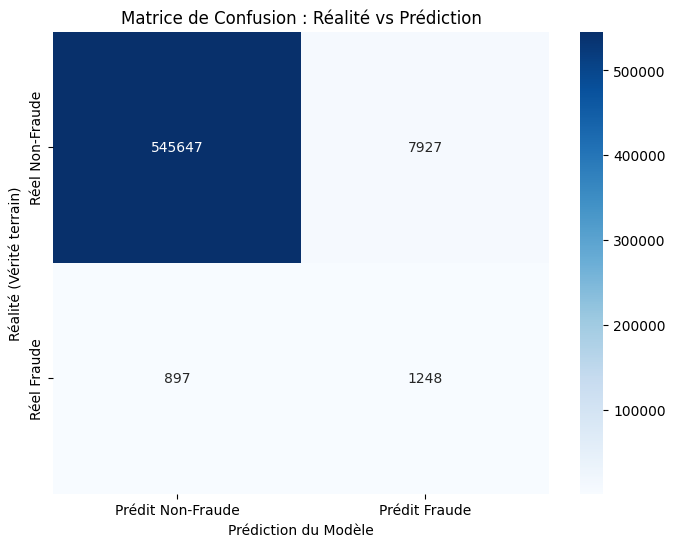


--- Rapport de Performance Détaillé ---
              precision    recall  f1-score   support

  Non-Fraude       1.00      0.99      0.99    553574
      Fraude       0.14      0.58      0.22      2145

    accuracy                           0.98    555719
   macro avg       0.57      0.78      0.61    555719
weighted avg       1.00      0.98      0.99    555719



In [27]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcul de la matrice de confusion
# On compare les vraies valeurs (df['is_fraud']) aux prédictions
conf_matrix = confusion_matrix(df['is_fraud'], predictions)

# 2. Création d'un affichage visuel propre
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prédit Non-Fraude', 'Prédit Fraude'],
            yticklabels=['Réel Non-Fraude', 'Réel Fraude'])

plt.xlabel('Prédiction du Modèle')
plt.ylabel('Réalité (Vérité terrain)')
plt.title('Matrice de Confusion : Réalité vs Prédiction')
plt.show()

# 3. Rapport détaillé (Précision, Rappel, F1-Score)
print("\n--- Rapport de Performance Détaillé ---")
print(classification_report(df['is_fraud'], predictions, target_names=['Non-Fraude', 'Fraude']))